In [237]:
import pandas as pd
import numpy as np

In [238]:
df = pd.read_csv("dataset_2.csv")

In [239]:
df.head()

,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


In [240]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64

In [241]:
import seaborn as sns

In [242]:
df.tail()

,Emotion,Text
34787,surprise,@MichelGW have you gift! Hope you like it! It'...
34788,joy,The world didnt give it to me..so the world MO...
34789,anger,A man robbed me today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO..."
34791,sadness,"I think about you baby, and I dream about you ..."


<Axes: xlabel='Emotion', ylabel='count'>

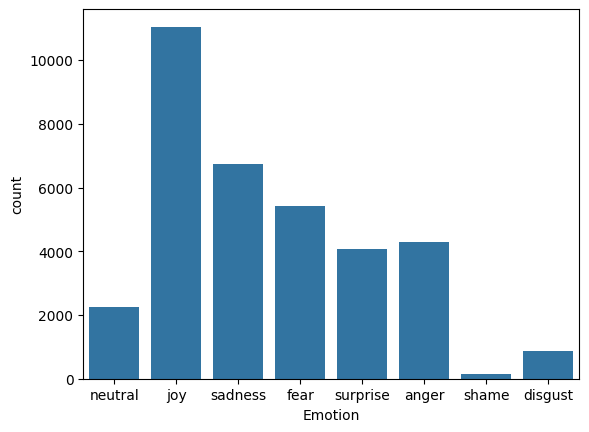

In [243]:
sns.countplot(x='Emotion',data=df)

In [244]:
# !pip install neattext

In [245]:
import neattext.functions as nfx

In [246]:
# dir(nfx)

In [247]:
df["new_Text"] = df["Text"].apply(nfx.remove_userhandles)

In [248]:
df["new_Text"] = df["Text"].apply(nfx.remove_stopwords)

In [249]:
df.head(3)

,Emotion,Text,new_Text
0,neutral,Why ?,?
1,joy,Sage Act upgrade on my to do list for tommorow.,Sage Act upgrade list tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,WAY HOMEGIRL BABY FUNERAL!!! MAN HATE FUNERALS...


In [250]:
df.tail()

,Emotion,Text,new_Text
34787,surprise,@MichelGW have you gift! Hope you like it! It'...,@MichelGW gift! Hope like it! hand wear ! It'l...
34788,joy,The world didnt give it to me..so the world MO...,world didnt me..so world DEFINITELY cnt away!!!
34789,anger,A man robbed me today .,man robbed today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO...","Youu JEALOUSY, #Losing YOU..."
34791,sadness,"I think about you baby, and I dream about you ...","think baby, dream time"


In [251]:
df["Text"].isna().sum()

0

In [252]:
(df["Text"]=="").sum()

0

In [253]:
df.tail()

,Emotion,Text,new_Text
34787,surprise,@MichelGW have you gift! Hope you like it! It'...,@MichelGW gift! Hope like it! hand wear ! It'l...
34788,joy,The world didnt give it to me..so the world MO...,world didnt me..so world DEFINITELY cnt away!!!
34789,anger,A man robbed me today .,man robbed today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO...","Youu JEALOUSY, #Losing YOU..."
34791,sadness,"I think about you baby, and I dream about you ...","think baby, dream time"


In [254]:
df["new_Text"] = df["new_Text"].str.lower()


In [255]:
df.head()

,Emotion,Text,new_Text
0,neutral,Why ?,?
1,joy,Sage Act upgrade on my to do list for tommorow.,sage act upgrade list tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,way homegirl baby funeral!!! man hate funerals...
3,joy,Such an eye ! The true hazel eye-and so brill...,eye ! true hazel eye-and brilliant ! regular f...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,@iluvmiasantos ugh babe.. hugggzzz u .! babe n...


In [256]:
df.tail()

,Emotion,Text,new_Text
34787,surprise,@MichelGW have you gift! Hope you like it! It'...,@michelgw gift! hope like it! hand wear ! it'l...
34788,joy,The world didnt give it to me..so the world MO...,world didnt me..so world definitely cnt away!!!
34789,anger,A man robbed me today .,man robbed today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO...","youu jealousy, #losing you..."
34791,sadness,"I think about you baby, and I dream about you ...","think baby, dream time"


In [257]:
df["new_Text"].isnull().sum()

0

In [258]:
df["new_Text"].isna().sum()

0

In [259]:
(df["Text"]=="").sum()

0

In [260]:
df.isnull().any(axis=1).sum()

0

In [261]:
df["Emotion"].unique()

array(['neutral', 'joy', 'sadness', 'fear', 'surprise', 'anger', 'shame',
       'disgust'], dtype=object)

In [262]:
emotion = df["Emotion"]

In [263]:
text  = df["new_Text"]

In [264]:
from sklearn.model_selection import train_test_split

In [265]:
X_train,X_test,Y_train,Y_test =train_test_split(text,emotion,test_size=0.3,random_state=42)

In [266]:
from sklearn.linear_model import LogisticRegression

In [267]:
from sklearn.pipeline import Pipeline

In [268]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[('tfidf', TfidfVectorizer()), ('lr', LogisticRegression())])


In [269]:
pipe.fit(X_train,Y_train)

C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('tfidf', TfidfVectorizer()), ('lr', LogisticRegression())])

In [270]:
# Fit the model to the training data
pipe.fit(X_train, Y_train)

# Evaluate the model on the test set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict labels
y_pred = pipe.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")

# Classification Report (includes precision, recall, F1)
print("Classification Report:")
print(classification_report(Y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))


Model Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

       anger       0.65      0.53      0.59      1283
     disgust       0.86      0.04      0.08       292
        fear       0.75      0.64      0.69      1645
         joy       0.55      0.83      0.66      3311
     neutral       0.64      0.32      0.43       675
     sadness       0.59      0.57      0.58      2015
       shame       0.69      0.25      0.37        36
    surprise       0.61      0.38      0.47      1181

    accuracy                           0.60     10438
   macro avg       0.67      0.44      0.48     10438
weighted avg       0.63      0.60      0.59     10438

Confusion Matrix:
[[ 685    0   56  315   24  169    1   33]
 [  38   12   22  135    2   64    1   18]
 [  68    1 1045  328   10  137    0   56]
 [  80    1  101 2739   56  226    1  107]
 [  28    0   16  321  215   77    0   18]
 [ 106    0   88  591   22 1151    1   56]
 [   3    0    4   16    0  

C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [274]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer

pipe_svm_linear = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('svm', CalibratedClassifierCV(LinearSVC(class_weight='balanced')))
])



In [275]:
pipe_svm_linear.fit(X_train,Y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('svm',
                 CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced')))])

In [276]:
# Fit the model to the training data
pipe_svm_linear.fit(X_train, Y_train)

# Evaluate the model on the test set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict labels
y_pred = pipe_svm_linear.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")

# Classification Report (includes precision, recall, F1)
print("Classification Report:")
print(classification_report(Y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

Model Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

       anger       0.62      0.57      0.59      1283
     disgust       0.65      0.18      0.29       292
        fear       0.73      0.70      0.72      1645
         joy       0.61      0.77      0.68      3311
     neutral       0.69      0.64      0.67       675
     sadness       0.59      0.56      0.57      2015
       shame       0.85      0.94      0.89        36
    surprise       0.55      0.42      0.48      1181

    accuracy                           0.63     10438
   macro avg       0.66      0.60      0.61     10438
weighted avg       0.63      0.63      0.62     10438

Confusion Matrix:
[[ 726    6   71  239   42  150    1   48]
 [  31   54   23   94    4   58    1   27]
 [  70    4 1148  226   10  122    0   65]
 [ 120    5  133 2542   81  271    1  158]
 [  34    0   14  108  435   62    0   22]
 [ 133    6  112  515   41 1126    2   80]
 [   0    0    0    2    0  

In [208]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the Random Forest pipeline
pipe_rf = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Train the model
pipe_rf.fit(X_train, Y_train)

# Predict
y_pred_rf = pipe_rf.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(Y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}\n")

print("Classification Report (Random Forest):")
print(classification_report(Y_test, y_pred_rf))

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(Y_test, y_pred_rf))


Random Forest Accuracy: 0.61

Classification Report (Random Forest):
              precision    recall  f1-score   support

       anger       0.67      0.49      0.57       836
     disgust       0.77      0.18      0.29       202
        fear       0.88      0.61      0.72      1104
         joy       0.54      0.84      0.66      2214
     neutral       0.50      0.73      0.59       481
     sadness       0.63      0.50      0.56      1327
       shame       0.85      0.96      0.90        23
    surprise       0.71      0.32      0.44       772

    accuracy                           0.61      6959
   macro avg       0.69      0.58      0.59      6959
weighted avg       0.65      0.61      0.60      6959

Confusion Matrix (Random Forest):
[[ 411    1   16  243   68   89    1    7]
 [  20   36    3   99    9   30    1    4]
 [  41    3  673  239   59   61    0   28]
 [  48    2   32 1859  114  119    1   39]
 [  13    0    6   83  350   26    0    3]
 [  64    2   25  497   59  661

In [209]:
# !pip install xgboost


In [210]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode target labels as integers
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

# Define the pipeline with XGBoost
pipe_xgb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=1))
])

# Train the model
pipe_xgb.fit(X_train, Y_train_encoded)

# Predict
y_pred_xgb = pipe_xgb.predict(X_test)

# Decode predictions back to original labels
y_pred_xgb_decoded = label_encoder.inverse_transform(y_pred_xgb)

# Evaluate
accuracy_xgb = accuracy_score(Y_test, y_pred_xgb_decoded)
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}\n")

print("Classification Report (XGBoost):")
print(classification_report(Y_test, y_pred_xgb_decoded))

print("Confusion Matrix (XGBoost):")
print(confusion_matrix(Y_test, y_pred_xgb_decoded))


C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\xgboost\core.py:158: UserWarning: [23:20:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.58

Classification Report (XGBoost):
              precision    recall  f1-score   support

       anger       0.75      0.44      0.56       836
     disgust       0.65      0.16      0.25       202
        fear       0.87      0.53      0.66      1104
         joy       0.47      0.89      0.62      2214
     neutral       0.75      0.29      0.42       481
     sadness       0.66      0.49      0.56      1327
       shame       0.83      0.87      0.85        23
    surprise       0.68      0.34      0.46       772

    accuracy                           0.58      6959
   macro avg       0.71      0.50      0.55      6959
weighted avg       0.65      0.58      0.56      6959

Confusion Matrix (XGBoost):
[[ 370    2   14  362    5   74    1    8]
 [  15   32    2  114    0   32    1    6]
 [  28    4  585  402    2   59    0   24]
 [  28    2   29 1964   28  109    1   53]
 [   6    0    2  302  140   28    0    3]
 [  37    7   27  566    8  653    0   29]
 [   0

In [211]:
from sklearn.naive_bayes import MultinomialNB

# Define the pipeline with Naive Bayes
pipe_naive = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('naive_bayes', MultinomialNB())  # Using Naive Bayes
])

# Train the model
pipe_naive.fit(X_train, Y_train)

# Predict
y_pred_nb = pipe_naive.predict(X_test)

# Evaluate
accuracy_nb = accuracy_score(Y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.2f}\n")

print("Classification Report (Naive Bayes):")
print(classification_report(Y_test, y_pred_nb))

print("Confusion Matrix (Naive Bayes):")
print(confusion_matrix(Y_test, y_pred_nb))


Naive Bayes Accuracy: 0.51

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

       anger       0.88      0.27      0.42       836
     disgust       0.00      0.00      0.00       202
        fear       0.88      0.44      0.59      1104
         joy       0.42      0.97      0.59      2214
     neutral       0.97      0.07      0.14       481
     sadness       0.67      0.41      0.51      1327
       shame       0.00      0.00      0.00        23
    surprise       0.82      0.17      0.29       772

    accuracy                           0.51      6959
   macro avg       0.58      0.29      0.32      6959
weighted avg       0.66      0.51      0.47      6959

Confusion Matrix (Naive Bayes):
[[ 228    0   16  509    0   82    0    1]
 [   5    0    3  169    0   24    0    1]
 [  10    0  491  526    0   61    0   16]
 [   2    0   15 2145    1   42    0    9]
 [   2    0    4  407   36   32    0    0]
 [   7    0   15  755    0  548    0 

C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\xgboost\core.py:158: UserWarning: [23:21:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Asus\anaconda3\envs\py39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Asus\AppData\Local\Temp\ipykernel_1072\4047405530.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is d

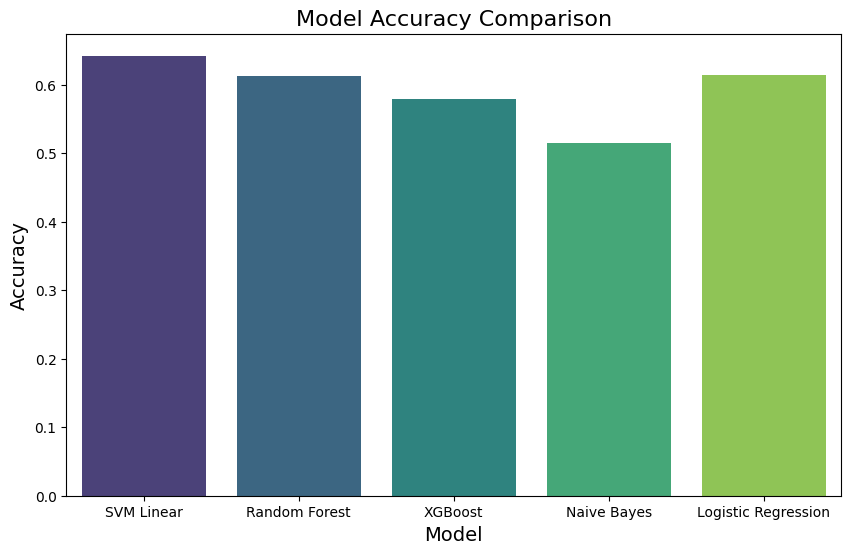

In [212]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the training labels, and transform the test labels
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

# List of all pipelines
pipelines = {
    'SVM Linear': pipe_svm_linear,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xgb,
    'Naive Bayes': pipe_naive,
    'Logistic Regression': pipe,  # Assuming you have defined 'pipe_naive' somewhere
}

# Store accuracy scores for comparison
accuracy_scores = {}

# Evaluate each model
for model_name, pipeline in pipelines.items():
    # Fit the model
    pipeline.fit(X_train, Y_train_encoded)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Decode predictions back to the original labels
    y_pred_decoded = label_encoder.inverse_transform(y_pred)
    
    # Calculate accuracy
    accuracy = accuracy_score(Y_test, y_pred_decoded)
    accuracy_scores[model_name] = accuracy

# Create a plot to visualize the accuracy of each model
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# Display the plot
plt.show()


In [271]:
ex1 = "i will kill u"

In [278]:
pipe_svm_linear.predict([ex1])

array(['sadness'], dtype=object)

In [279]:
# Prediction Prob
pipe.predict_proba([ex1])

array([[0.17243111, 0.022527  , 0.18376606, 0.13246154, 0.08212381,
        0.30800729, 0.0052175 , 0.09346568]])

In [280]:
import joblib
pipeline_file = open("model.pkl","wb")
joblib.dump(pipe_svm_linear,pipeline_file)
pipeline_file.close()